In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Professional styling for the 2:00 PM pitch
plt.style.use('ggplot')
%matplotlib inline

In [10]:
# Update path if necessary
df = pd.read_csv('Zomato Dataset.csv')

print("--- Missing Values Audit ---")
print(df.isnull().sum())
print("\n--- Data Types ---")
print(df.dtypes)

--- Missing Values Audit ---
ID                                0
Delivery_person_ID                0
Delivery_person_Age            1854
Delivery_person_Ratings        1908
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1731
Time_Order_picked                 0
Weather_conditions              616
Road_traffic_density            601
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries             993
Festival                        228
City                           1200
Time_taken (min)                  0
dtype: int64

--- Data Types ---
ID                                 str
Delivery_person_ID                 str
Delivery_person_Age            float64
Delivery_person_Ratings        float64
Restaurant_latitude            float64
Restaurant_longitude   

In [11]:
# 1. Clean Numerical Columns (Ensure they are floats)
df['Delivery_person_Age'] = pd.to_numeric(df['Delivery_person_Age'], errors='coerce')
df['Delivery_person_Ratings'] = pd.to_numeric(df['Delivery_person_Ratings'], errors='coerce')

# 2. Smart Imputation: Filling holes in the data
# We use median for Age and mean for Ratings to maintain stability
df['Delivery_person_Age'] = df['Delivery_person_Age'].fillna(df['Delivery_person_Age'].median())
df['Delivery_person_Ratings'] = df['Delivery_person_Ratings'].fillna(df['Delivery_person_Ratings'].mean())

# 3. Handling Categorical Noise
# Replacing 'NaN' in traffic and city with 'Unknown'
df['Road_traffic_density'] = df['Road_traffic_density'].fillna('Unknown')
df['City'] = df['City'].fillna('Unknown')

print("Cleaning complete. All missing numerical values imputed.")

Cleaning complete. All missing numerical values imputed.


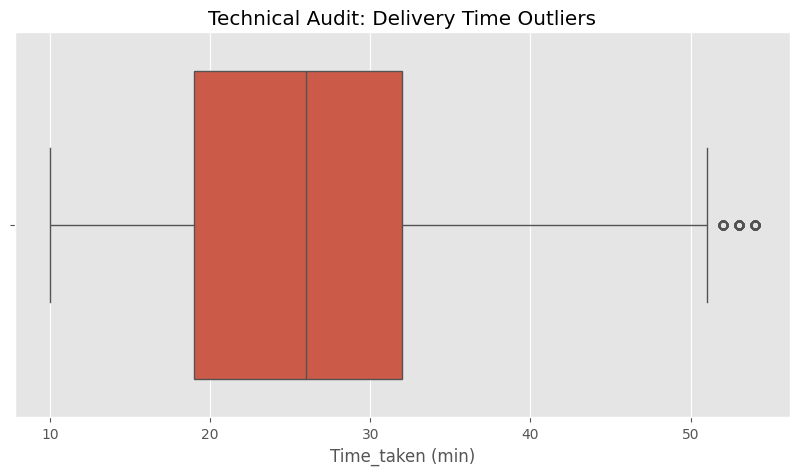

In [12]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['Time_taken (min)'])
plt.title('Technical Audit: Delivery Time Outliers')
plt.show()
# Logic: These outliers represent extreme delivery delays (60+ mins) 
# which we must investigate for 'Hidden Signals'.

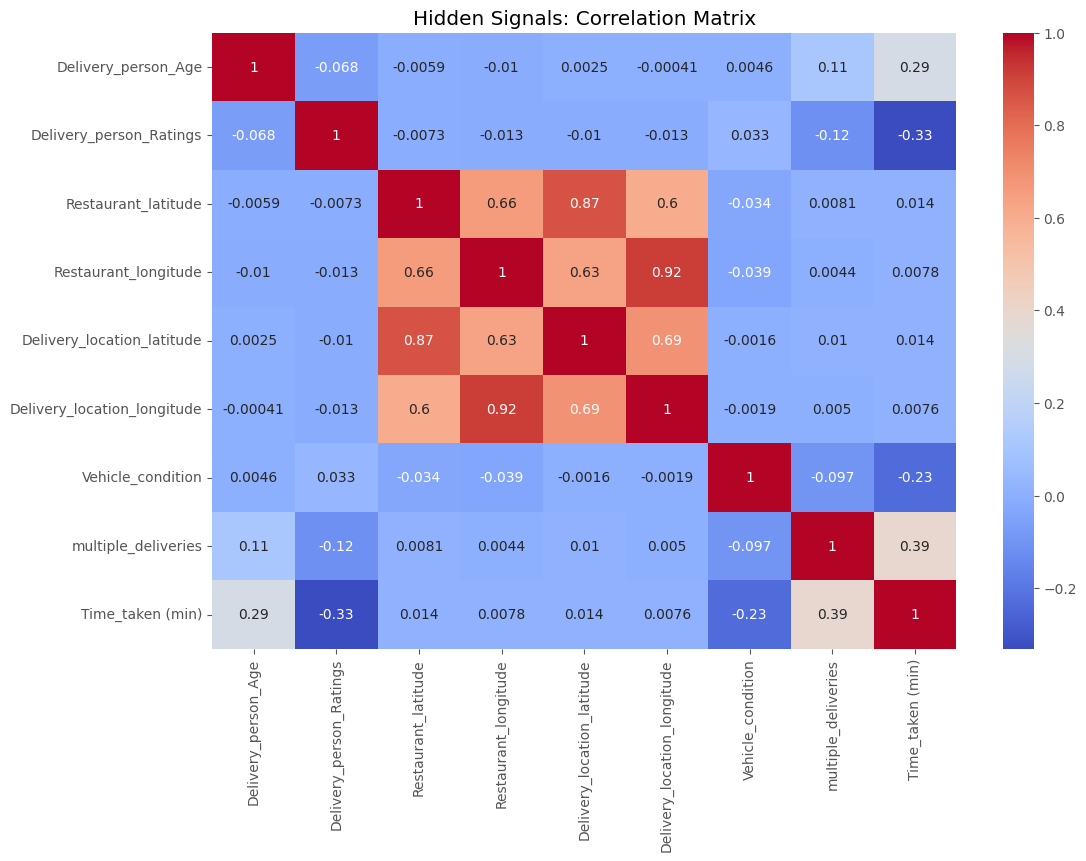

In [13]:
plt.figure(figsize=(12, 8))
# Only correlate numeric columns
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm')
plt.title('Hidden Signals: Correlation Matrix')
plt.show()

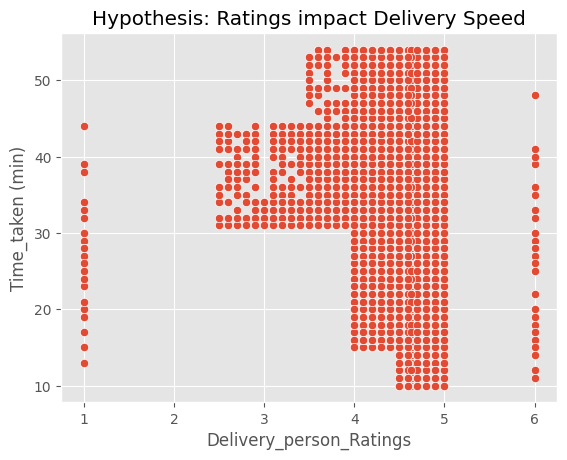

In [14]:
# Hypothesis: Does a higher delivery person rating result in faster deliveries?
sns.scatterplot(x='Delivery_person_Ratings', y='Time_taken (min)', data=df)
plt.title('Hypothesis: Ratings impact Delivery Speed')
plt.show()

In [15]:
df.to_csv('Zomato_Delivery_Cleaned.csv', index=False)
print("Cleaned data saved as 'Zomato_Delivery_Cleaned.csv'.")

Cleaned data saved as 'Zomato_Delivery_Cleaned.csv'.


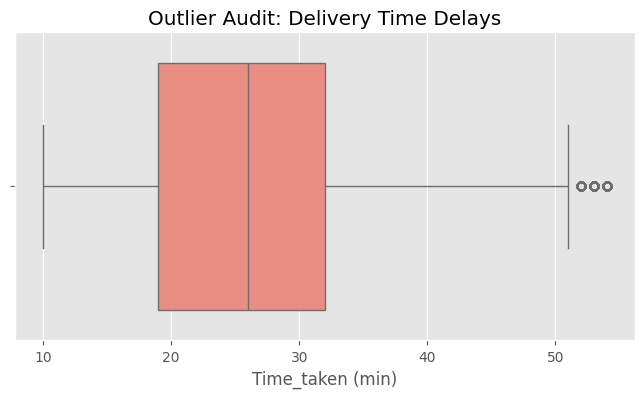

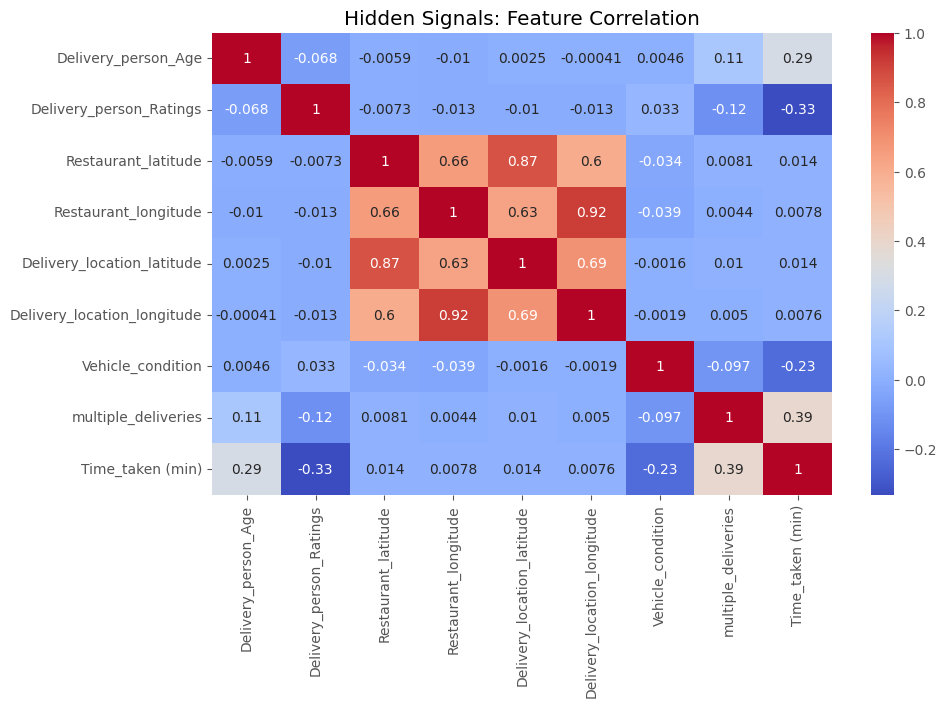

C:\Users\sur3s\AppData\Local\Temp\ipykernel_3924\3559761738.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Road_traffic_density', y='Time_taken (min)', data=df, palette='viridis')


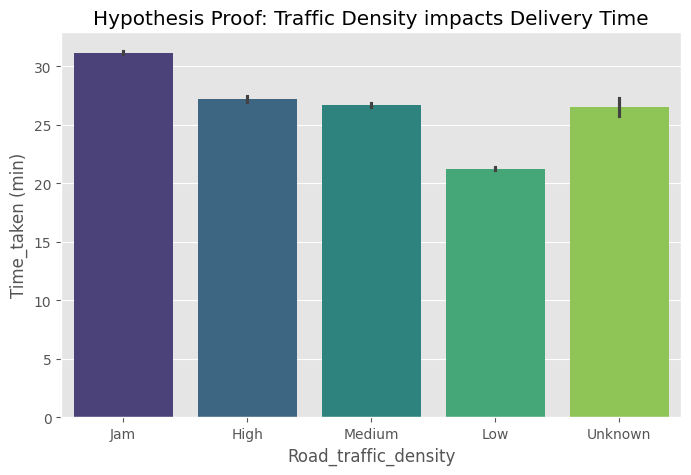

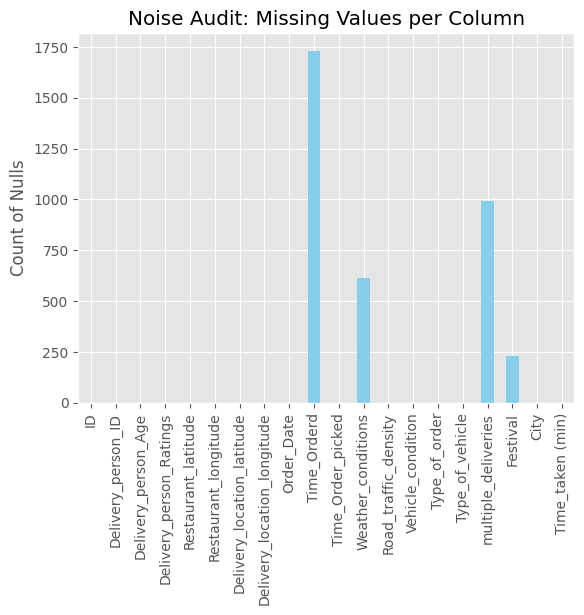

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Outlier Audit
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Time_taken (min)'], color='salmon')
plt.title('Outlier Audit: Delivery Time Delays')
plt.show()

# 2. Hidden Signals Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm')
plt.title('Hidden Signals: Feature Correlation')
plt.show()

# 3. Hypothesis Proof (Traffic vs Time)
plt.figure(figsize=(8, 5))
sns.barplot(x='Road_traffic_density', y='Time_taken (min)', data=df, palette='viridis')
plt.title('Hypothesis Proof: Traffic Density impacts Delivery Time')
plt.show()

# 4. Noise/Missing Values
df.isnull().sum().plot(kind='bar', color='skyblue')
plt.title('Noise Audit: Missing Values per Column')
plt.ylabel('Count of Nulls')
plt.show()

In [1]:
import pandas as pd

# Load the cleaned dataset
df = pd.read_csv('Zomato_Delivery_Cleaned.csv')

# Extract the 3-letter city code from Delivery_person_ID
df['City_Code'] = df['Delivery_person_ID'].str[:3]

# Define Regional Mappings
north_codes = ['JAP', 'AGR', 'LUD', 'KNP', 'ALH', 'DEH', 'IND', 'BHP', 'RAN', 'KOL']
south_codes = ['BAN', 'HYD', 'MYS', 'COI', 'CHE', 'KOC']

# Filter and Save North India Data
df_north = df[df['City_Code'].isin(north_codes)].copy()
df_north.to_csv('Zomato_North_India.csv', index=False)

# Filter and Save South India Data
df_south = df[df['City_Code'].isin(south_codes)].copy()
df_south.to_csv('Zomato_South_India.csv', index=False)

print("North and South India CSV files have been created successfully.")

North and South India CSV files have been created successfully.


In [2]:
import pandas as pd

# Load Regional Data
df_north = pd.read_csv('Zomato_North_India.csv')
df_south = pd.read_csv('Zomato_South_India.csv')

# Segregate North India by City Type
df_north[df_north['City'] == 'Urban'].to_csv('Zomato_North_Urban.csv', index=False)
df_north[df_north['City'] == 'Metropolitian'].to_csv('Zomato_North_Metropolitian.csv', index=False)

# Segregate South India by City Type
df_south[df_south['City'] == 'Urban'].to_csv('Zomato_South_Urban.csv', index=False)
df_south[df_south['City'] == 'Metropolitian'].to_csv('Zomato_South_Metropolitian.csv', index=False)

print("4 targeted CSV files have been created successfully.")

4 targeted CSV files have been created successfully.


--- FINAL LOGISTICS AUDIT ---
[North Metro] Avg Time: 27.42m | Peak: 19.0:00 | Traffic Delay: 9.78m
[North Urban] Avg Time: 23.17m | Peak: 22.0:00 | Traffic Delay: 8.63m
[South Metro] Avg Time: 27.29m | Peak: 21.0:00 | Traffic Delay: 9.79m
[South Urban] Avg Time: 22.73m | Peak: 22.0:00 | Traffic Delay: 8.24m


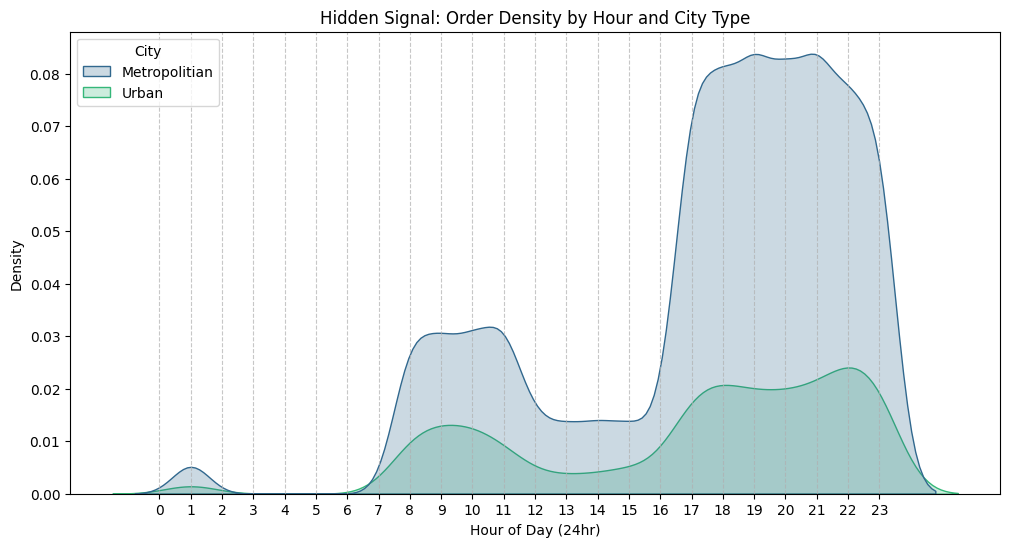

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the Cleaned Dataset
# Using the file you've already sanitized
df = pd.read_csv('Zomato_Delivery_Cleaned.csv')

# 2. Regional Feature Engineering (North vs South)
df['City_Code'] = df['Delivery_person_ID'].str[:3]
north_codes = ['JAP', 'AGR', 'LUD', 'KNP', 'ALH', 'DEH', 'IND', 'BHP', 'RAN', 'KOL']
south_codes = ['BAN', 'HYD', 'MYS', 'COI', 'CHE', 'KOC']

def map_region(code):
    if code in north_codes: return 'North India'
    if code in south_codes: return 'South India'
    return 'Other'

df['Region'] = df['City_Code'].apply(map_region)

# 3. Time Feature Engineering (Extracting Hours)
def extract_hour(time_str):
    try:
        return int(str(time_str).split(':')[0])
    except:
        return np.nan

df['Order_Hour'] = df['Time_Orderd'].apply(extract_hour)
df = df.dropna(subset=['Order_Hour']) # Removing 'Noise' in time data

# 4. Creating Segregated Market Files
# North India Split
df[(df['Region'] == 'North India') & (df['City'] == 'Urban')].to_csv('North_Urban.csv', index=False)
df[(df['Region'] == 'North India') & (df['City'] == 'Metropolitian')].to_csv('North_Metro.csv', index=False)

# South India Split
df[(df['Region'] == 'South India') & (df['City'] == 'Urban')].to_csv('South_Urban.csv', index=False)
df[(df['Region'] == 'South India') & (df['City'] == 'Metropolitian')].to_csv('South_Metro.csv', index=False)

# 5. Comparative Statistical Analysis
segments = {
    "North Metro": df[(df['Region'] == 'North India') & (df['City'] == 'Metropolitian')],
    "North Urban": df[(df['Region'] == 'North India') & (df['City'] == 'Urban')],
    "South Metro": df[(df['Region'] == 'South India') & (df['City'] == 'Metropolitian')],
    "South Urban": df[(df['Region'] == 'South India') & (df['City'] == 'Urban')]
}

print("--- FINAL LOGISTICS AUDIT ---")
for name, data in segments.items():
    avg_time = data['Time_taken (min)'].mean()
    peak_hr = data['Order_Hour'].mode()[0]
    jam_delay = data[data['Road_traffic_density'] == 'Jam']['Time_taken (min)'].mean() - \
                data[data['Road_traffic_density'] == 'Low']['Time_taken (min)'].mean()
    
    print(f"[{name}] Avg Time: {avg_time:.2f}m | Peak: {peak_hr}:00 | Traffic Delay: {jam_delay:.2f}m")

# 6. Visualization: Peak Hour Signal
plt.figure(figsize=(12, 6))
sns.kdeplot(data=df[df['City'].isin(['Urban', 'Metropolitian'])], 
            x='Order_Hour', hue='City', fill=True, palette='viridis')
plt.title('Hidden Signal: Order Density by Hour and City Type')
plt.xlabel('Hour of Day (24hr)')
plt.xticks(range(0, 24))
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()